In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [304]:
df = pd.read_csv('train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [305]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [306]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [307]:
counts = df["Sex"].value_counts()
counts

Sex
male      577
female    314
Name: count, dtype: int64

In [308]:
df[df["Survived"] == 1]["Sex"].value_counts()

Sex
female    233
male      109
Name: count, dtype: int64

In [309]:
df[df["Survived"] == 1]["Sex"].value_counts() / counts

Sex
female    0.742038
male      0.188908
Name: count, dtype: float64

In [310]:
#transforming cabin to a potentially useful feature 
df["Cabin_known"] = df["Cabin"].notnull()
df = df.drop("Cabin", axis=1)
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_known
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,False
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q,False
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,True
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,False
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,False
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,False


In [311]:
df = df.dropna(subset="Embarked")
#removing 3 outliers
df = df[df["Fare"] < 500]
df.info()

<class 'pandas.DataFrame'>
Index: 886 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  886 non-null    int64  
 1   Survived     886 non-null    int64  
 2   Pclass       886 non-null    int64  
 3   Name         886 non-null    str    
 4   Sex          886 non-null    str    
 5   Age          709 non-null    float64
 6   SibSp        886 non-null    int64  
 7   Parch        886 non-null    int64  
 8   Ticket       886 non-null    str    
 9   Fare         886 non-null    float64
 10  Embarked     886 non-null    str    
 11  Cabin_known  886 non-null    bool   
dtypes: bool(1), float64(2), int64(5), str(4)
memory usage: 118.5 KB


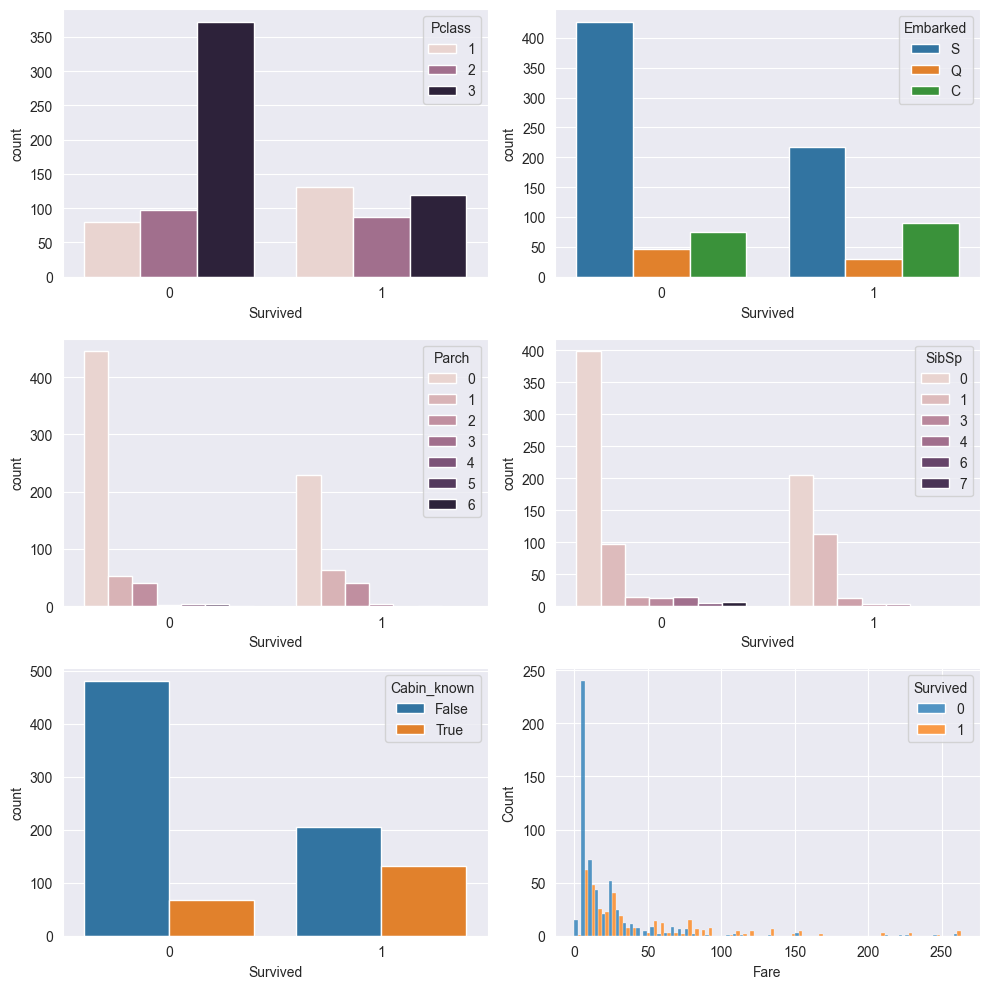

In [312]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
sns.countplot(df, x=df["Survived"], hue="Pclass", legend=True, ax=axes[0][0])
sns.countplot(df, x=df["Survived"], hue="Embarked", legend=True, ax=axes[0][1])
sns.countplot(df, x=df["Survived"], hue="Parch", legend=True, ax=axes[1][0])
sns.countplot(df, x=df["Survived"], hue="SibSp", legend=True, ax=axes[1][1])
sns.countplot(df, x=df["Survived"], hue="Cabin_known", legend=True, ax=axes[2][0])
sns.histplot(df, x=df["Fare"], hue="Survived", legend=True,  multiple="dodge", ax=axes[2][1])

plt.tight_layout()
plt.show()

In [313]:
df["Numerical_ticket"] = df["Ticket"].str.isnumeric()
df = df.drop("Ticket", axis=1)
df["Isfemale"] = df["Sex"] == "female"

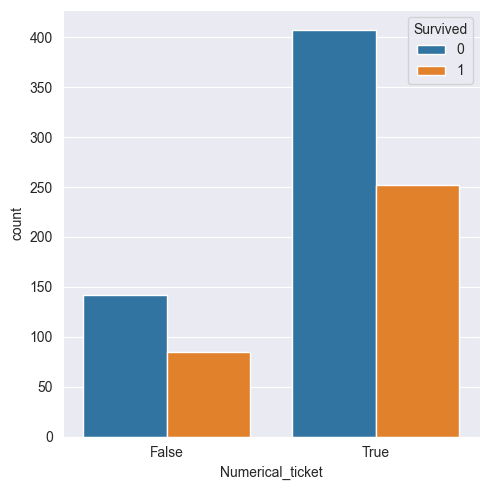

In [314]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.countplot(df, x=df["Numerical_ticket"], hue="Survived", legend=True)

plt.tight_layout()
plt.show()

In [315]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

cols_to_drop = ["Sex", "PassengerId", "Name"]
df = df.drop(columns=cols_to_drop)

onehot = OneHotEncoder(sparse_output=False, drop="first").set_output(transform="pandas")
cat_cols = ["Pclass", "Embarked"]

embarked = onehot.fit_transform(df[cat_cols])
df = pd.concat([df, embarked], axis=1).drop(columns=cat_cols)

X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [316]:
minmax = MinMaxScaler(clip=True)
standard = StandardScaler()
imputer = SimpleImputer(strategy="mean")

X_train["Age"] = imputer.fit_transform(X_train[["Age"]])
X_test["Age"] = imputer.transform(X_test[["Age"]])

minmax_cols = ["SibSp", "Parch"]
standard_cols = ["Age", "Fare"]

X_train[minmax_cols] = minmax.fit_transform(X_train[minmax_cols])
X_test[minmax_cols] = minmax.transform(X_test[minmax_cols])

X_train[standard_cols] = standard.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard.transform(X_test[standard_cols])

In [317]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
svc = SVC(kernel="poly")
score = cross_val_score(svc, X_train, y_train, cv=10)
score.mean()

np.float64(0.8362374245472836)

In [318]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "gamma": ["scale", "auto"]
}
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, scoring="accuracy")
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'gamma': 'scale', 'kernel': 'poly'}

In [319]:
test_data = pd.read_csv('test.csv')
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 52.8 KB


In [320]:
test_data["Cabin_known"] = test_data["Cabin"].notnull()
test_data = test_data.drop("Cabin", axis=1)

test_data["Fare"] = test_data["Fare"].fillna(test_data["Fare"].mean())
test_df = test_data.copy()

test_data["Numerical_ticket"] = test_data["Ticket"].str.isnumeric()
test_data = test_data.drop("Ticket", axis=1)

test_data["Isfemale"] = test_data["Sex"] == "female"

test_data = test_data.drop(columns=cols_to_drop)

embarked = onehot.transform(test_data[cat_cols])
test_data = pd.concat([test_data, embarked], axis=1).drop(columns=cat_cols)

test_data["Age"] = imputer.transform(test_data[["Age"]])
test_data[minmax_cols] = minmax.transform(test_data[minmax_cols])
test_data[standard_cols] = standard.transform(test_data[standard_cols])

In [321]:
svc.fit(X_train, y_train)
pred = svc.predict(test_data)
df_pred = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": pred})
df_pred.to_csv("test_pred.csv", index=False)

In [322]:
df_pred.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


#### got 0.76076 🙄